# Langevin versus Gompertz: fits and held-out post-intervention prediction

Parts 1 and 2 preserve the original training datasets and Langevin parameter
values. Gompertz is refitted with its actual grouped likelihood, without
probability floors. Thus its parameters and all downstream results can change.
The supplied Langevin parameters remain historical simulation-based fits;
their original fitting procedure used a simulation-resolution floor and
constraints. This notebook does not redo that training pipeline.

Baseline fit scores and nominal AIC are descriptive; they are not accompanied
by classical fitted-model Vuong p-values. Part 3 compares both fixed predictions
on independent Auxin_day_21 observations conditional on survival past day 21.
Positive paired log-score differences favor Langevin. A paired worm bootstrap
gives uncertainty conditional on the fitted predictions. It does not include
training uncertainty, replicate clustering, or finite-path simulation error.
RMST and curve-distance checks at days 35 and 39 remain exploratory sensitivity
analyses. Neither endpoint is described as prespecified.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import NelsonAalenFitter
from scipy.optimize import differential_evolution, minimize
from scipy.stats import binomtest, linregress, norm

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
SRC_DIR = NOTEBOOK_DIR.parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data import kaplan_meier_curve, load_raw_survival_data
from model import km_from_fpt, simulate_fpt_and_state, simulate_two_phase

N_PATHS = 1_000_000  # Production Monte Carlo resolution; keep fixed across models/tests.

raw_data = load_raw_survival_data()
for name, d in raw_data.items():
    print(f"{name}: n={d.n_total} worms, ages {d.t.min():.0f}-{d.t.max():.0f} days")

DMSO_day_10: n=232 worms, ages 10-25 days
Auxin_day_10: n=81 worms, ages 10-42 days
Auxin_day_21: n=247 worms, ages 10-39 days


## Shared likelihood machinery

Both model families are scored with the same grouped-data log-likelihood
construction used throughout this project
(`0_auto_fit_parameters_mle.py`'s `_weighted_neg_log_lik`): each observed
death at age `t_i` contributes the model's own interval probability mass
`S(t_(i-1)) - S(t_i)` (`t_(0)=0`, `S(0)=1`); each censored worm at `t_i`
contributes the model's survival probability `S(t_i)`. The two model
families differ only in how `S` is produced -- closed-form for Gompertz,
simulated for our Langevin model -- everything else about how a
log-likelihood is built from `S` is identical, so neither model gets an
easier scoring rule than the other.

`aic`, `report_fit`, and `report_delta_aic` below are the only functions
that print/format results -- Parts 1-3 all call them instead of each
formatting its own `logL`/`k`/`AIC` output, so all three parts report
identically and can't drift apart.

In [ ]:
def _grouped_death_censor_weights(d):
    """(t_unique, death_weight, censor_weight) for one GroupedSurvivalData."""
    t_unique = np.unique(d.t)
    death_weight = np.array([d.weight[(d.t == t) & (d.event_observed == 1)].sum() for t in t_unique])
    censor_weight = np.array([d.weight[(d.t == t) & (d.event_observed == 0)].sum() for t in t_unique])
    return t_unique, death_weight, censor_weight


def age_group_table(d):
    """Per-observed-age N at risk / died / censored for one condition --
    the raw counts behind every hazard/fit in this notebook (deaths and
    censoring at each age come straight from `d`; `n_at_risk` is everyone
    not yet dead or censored *before* that age, i.e. the same risk set a
    Kaplan-Meier/Nelson-Aalen/Cox estimator would use)."""
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    n_at_risk = d.n_total - np.concatenate(([0.0], np.cumsum(death_weight + censor_weight)[:-1]))
    return pd.DataFrame({
        "age": t_unique.astype(int),
        "n_at_risk": n_at_risk.astype(int),
        "n_died": death_weight.astype(int),
        "n_censored": censor_weight.astype(int),
    })

In [ ]:
for name, d in raw_data.items():
    print(f"\n{name}:")
    print(age_group_table(d).to_string(index=False))


DMSO_day_10:
 age  n_at_risk  n_died  n_censored
  10        232       5          19
  11        208       6           9
  15        193      27           0
  18        166      48           0
  21        118      71           0
  23         47      37           0
  24         10       6           0
  25          4       4           0

Auxin_day_10:
 age  n_at_risk  n_died  n_censored
  10         81       4          13
  11         64       1           4
  15         59       5           0
  18         54       2           0
  21         52       7           0
  23         45       8           0
  24         37       1           0
  25         36       1           0
  28         35       1           0
  30         34      10           0
  32         24       9           0
  35         15      10           0
  37          5       3           0
  39          2       1           0
  42          1       1           0

Auxin_day_21:
 age  n_at_risk  n_died  n_censored
  10        247     

In [ ]:
def _validated_log_survival(log_s):
    """Validate an unmodified survival distribution represented in log space."""
    log_s = np.asarray(log_s, dtype=float)
    if (log_s.ndim != 1 or log_s.size < 2 or np.any(np.isnan(log_s))
            or np.any(log_s > 0) or log_s[0] != 0
            or np.any(log_s[1:] > log_s[:-1])):
        raise ValueError("log S must start at zero and be nonincreasing, without NaNs.")
    return log_s


def _log_survival_from_S(s):
    s = np.asarray(s, dtype=float)
    if np.any(~np.isfinite(s)) or np.any(s < 0) or np.any(s > 1):
        raise ValueError("Survival probabilities must be finite and in [0, 1].")
    with np.errstate(divide="ignore"):
        return _validated_log_survival(np.log(s))


def _log_interval_mass(log_s):
    """log(S(left)-S(right)), without subtraction cancellation or floors."""
    log_s = _validated_log_survival(log_s)
    left, right = log_s[:-1], log_s[1:]
    out = np.full(left.size, -np.inf)
    positive_left = np.isfinite(left)
    with np.errstate(divide="ignore", invalid="ignore"):
        out[positive_left] = (left[positive_left]
                             + np.log(-np.expm1(right[positive_left] - left[positive_left])))
    return out


def _neg_log_lik_from_logS(log_s, death_weight, censor_weight):
    values = np.r_[_log_interval_mass(log_s), np.asarray(log_s)[1:]]
    weights = np.r_[death_weight, censor_weight]
    if values.shape != weights.shape:
        raise ValueError("Survival grid and observation weights must align.")
    active = weights > 0
    # Impossible unobserved bins contribute zero, never 0 * -inf.
    return -float(weights[active] @ values[active])


def _log_lik_contributions_from_S(S_at_grid, death_weight, censor_weight):
    log_s = _log_survival_from_S(S_at_grid)
    return (np.r_[_log_interval_mass(log_s), log_s[1:]],
            np.r_[death_weight, censor_weight])


def _neg_log_lik_from_S(S_at_grid, death_weight, censor_weight):
    return _neg_log_lik_from_logS(_log_survival_from_S(S_at_grid), death_weight, censor_weight)


def conditional_predictive_comparison(d, log_s_a, log_s_b, *, landmark=21.0,
                                     tau=None, n_boot=20_000, seed=20260919,
                                     confidence=0.95):
    """Paired held-out log-score comparison; positive values favor model A.

    Both log-survival arrays align with [0, *np.unique(d.t)]. Models must
    be trained independently of d. No AIC correction applies to these
    fixed predictions. Integer grouped counts are resampled as worms,
    preserving each worm's paired scores under A and B.

    tau=None scores all recorded post-landmark outcomes without choosing
    an RMST endpoint. A finite tau administratively censors later outcomes
    and must coincide with an inspection age. Never condition on death by
    the last observed age: the model tail remains part of its distribution.
    Censor scores assume independent/noninformative censoring with a common
    observation mechanism for both models. Replicate clustering cannot be
    recovered from these aggregated files; inference assumes iid worms.

    Returns a percentile paired-bootstrap CI and a normal-approximation
    two-sided p-value as a diagnostic, not a classical fitted-model Vuong
    claim. Training-fit and finite-simulation uncertainty are excluded.
    """
    t, e, w = (np.asarray(x, dtype=float) for x in (d.t, d.event_observed, d.weight))
    if (t.ndim != 1 or not t.size or e.shape != t.shape or w.shape != t.shape
            or np.any(~np.isfinite(t)) or np.any(t <= 0)
            or np.any(~np.isfinite(w)) or np.any(w < 0) or np.any(w != np.floor(w))
            or np.any(~np.isin(e, [0, 1]))):
        raise ValueError("Require parallel positive ages, binary events and integer nonnegative counts.")
    if (isinstance(n_boot, (bool, np.bool_)) or not isinstance(n_boot, (int, np.integer))
            or n_boot < 2 or not 0 < confidence < 1):
        raise ValueError("Require integer n_boot >= 2 and 0 < confidence < 1.")
    grid = np.r_[0., np.unique(t)]
    if not np.isfinite(landmark) or landmark not in grid:
        raise ValueError("landmark must be an inspection age.")
    if tau is not None and (not np.isfinite(tau) or tau <= landmark or tau not in grid):
        raise ValueError("tau must be an inspection age after landmark, or None.")
    logs = [_validated_log_survival(s) for s in (log_s_a, log_s_b)]
    if any(s.shape != grid.shape for s in logs):
        raise ValueError("Each log-survival vector must align with [0, *unique ages].")
    landmark_idx = np.searchsorted(grid, landmark)
    if any(not np.isfinite(s[landmark_idx]) for s in logs):
        raise ValueError("Both models must give positive landmark survival.")
    keep = (t > landmark) & (w > 0)
    t, e, w = t[keep], e[keep], w[keep].astype(int)
    n = int(w.sum())
    if n < 2:
        raise ValueError("At least two observed post-landmark worms are required.")
    if tau is not None:
        e = np.where(t > tau, 0, e)
        t = np.minimum(t, tau)
    idx = np.searchsorted(grid, t)
    score = []
    for label, s in zip(("A", "B"), logs):
        interval_logp = _log_interval_mass(s)
        per_row = np.where(e == 1, interval_logp[idx - 1], s[idx]) - s[landmark_idx]
        if np.any(~np.isfinite(per_row)):
            bad = t[~np.isfinite(per_row)].tolist()
            raise ValueError(f"Model {label} has zero/unresolved probability for observed ages {bad}. "
                             "Increase simulation resolution or supply stable log probabilities; no floor is used.")
        score.append(per_row)
    differences = score[0] - score[1]
    mean = float(w @ differences / n)
    variance = float(w @ (differences - mean)**2 / (n - 1))
    se = np.sqrt(variance / n)
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    # Multinomial frequencies are exactly a paired worm-level bootstrap.
    for start in range(0, n_boot, 1000):
        count = min(1000, n_boot - start)
        boot[start:start + count] = rng.multinomial(n, w / n, size=count) @ differences / n
    q = (1 - confidence) / 2
    lo, hi = np.quantile(boot, [q, 1-q])
    degenerate = variance == 0
    if degenerate:
        z, p = np.nan, np.nan
        status = "degenerate empirical score variance; uncertainty not estimable"
    else:
        z = mean / se
        p = float(2 * norm.sf(abs(z)))
        status = "conditional on fixed training fits; iid worms; exploratory"
    rows = pd.DataFrame({"age": t, "event_observed": e.astype(int), "count": w,
                         "log_score_a": score[0], "log_score_b": score[1],
                         "log_score_difference": differences,
                         "total_log_score_difference": w * differences})
    return {
        "n_landmark": n, "landmark": landmark,
        "endpoint": "all recorded outcomes" if tau is None else float(tau),
        "logL_a": float(w @ score[0]), "logL_b": float(w @ score[1]),
        "mean_log_score_difference": mean, "total_log_score_difference": n * mean,
        "standard_error": float(se), "ci_low": float(lo), "ci_high": float(hi),
        "confidence": confidence, "normal_z_diagnostic": float(z),
        "normal_p_two_sided_diagnostic": p, "bootstrap_standard_error": float(boot.std(ddof=1)),
        "n_boot": n_boot, "seed": seed, "status": status,
        "bootstrap_mean_differences": boot, "contributions": rows,
    }



def aic(logL, k):
    return 2 * k - 2 * logL


def report_fit(label, logL, k, note=""):
    if not np.isfinite(logL):
        print(f"{label}: logL and nominal AIC unavailable: zero simulated mass in an observed bin. "
              "Increase simulation resolution; no probability floor is applied.")
        return np.nan
    suffix = f", {note}" if note else ""
    value = aic(logL, k)
    print(f"{label}: logL={logL:.4g} (k={k}{suffix}); nominal AIC={value:.4g} (descriptive)")
    return value


def report_delta_aic(condition, aic_gomp, aic_langevin):
    if not np.isfinite(aic_gomp) or not np.isfinite(aic_langevin):
        print(f"Nominal delta AIC for {condition}: unavailable; unresolved model likelihood.")
        return np.nan
    delta = aic_gomp - aic_langevin
    print(f"Nominal delta AIC (Gompertz - Langevin), {condition}: {delta:+.4g}; exploratory")
    return delta

### Monte-Carlo noise in the Langevin model's simulated logL

Gompertz's likelihood is closed-form and exact; the Langevin model's is
estimated by simulating `n_paths` first-passage times, so it carries its
own Monte-Carlo noise that a single logL number doesn't reveal. Re-running
the same evaluation at several seeds and reporting the resulting spread
checks that the observed logL/AIC gap between the two models isn't
smaller than -- or an artifact of -- that simulation noise.

This checks numerical simulation spread, not sampling uncertainty of the
real cohort and not uncertainty from estimating the training parameters.

Run at `n_paths=100_000` (not the production `N_PATHS=1_000_000` used
for the headline numbers) -- ten independent replicates at that size are
enough to characterize the *scale* of simulation noise, and doing so at
full production resolution would cost ten times as much for no added
information here.

In [ ]:
def langevin_logL_monte_carlo_se(nll_fn, *args, n_seeds=10, base_seed=1000, **kwargs):
    """Historical name; reports between-simulation SD, not SE of the mean."""
    logLs = np.array([-nll_fn(*args, seed=base_seed+i, **kwargs) for i in range(n_seeds)])
    unresolved = np.count_nonzero(~np.isfinite(logLs))
    if unresolved:
        print(f"MC diagnostic unavailable: {unresolved}/{n_seeds} seeds have unresolved observed bins. "
              "Increase paths; finite seeds are not selectively averaged.")
        return np.nan, np.nan
    return logLs.mean(), logLs.std(ddof=1)


def report_mc_noise(condition, logL_mean, logL_se, logL_gomp):
    if not np.all(np.isfinite([logL_mean, logL_se, logL_gomp])):
        print(f"Simulation-spread diagnostic for {condition}: unavailable at this resolution.")
        return
    print(f"Langevin logL simulation diagnostic, {condition}: mean={logL_mean:.4g}, "
          f"between-run SD={logL_se:.3g}; mean logL difference={logL_mean-logL_gomp:+.4g}")

### Gompertz hazard model

Classical Gompertz hazard `M(t) = M0*exp(alpha_g*t)`, with closed-form
survival `S(t) = exp(-(M0/alpha_g)*(exp(alpha_g*t) - 1))` -- an explicit
function of calendar age, no state variable or mechanism at all.

**The two-piece version continues from the mortality *rate itself*
reached at `t_switch`, not from a shared baseline `M0`.** A day-21 worm
has already accumulated 21 days of DMSO-driven mortality risk -- it
can't lose that damage at the moment of intervention, so its hazard
`M(t)` cannot legitimately *drop* at `t_switch`. (An earlier version of
this construction held `M0` fixed across both phases and switched only
`alpha_g`; because `M(t) = M0*exp(alpha_g*t)` moves the whole curve, not
just its slope, reusing the same `M0` with a *shallower* post-switch
`alpha_g` made the hazard drop discontinuously right at the switch --
biologically backwards, and the actual bug this section fixes.) Instead:
phase 1 is the ordinary Gompertz hazard `M1(t) = M0*exp(alpha_g1*t)` up
to `t_switch`; phase 2 picks up exactly at phase 1's own hazard level,
`M_switch = M1(t_switch)`, and grows from there at the new rate
`alpha_g2`: `M2(t) = M_switch*exp(alpha_g2*(t - t_switch))`. `M(t)` is
therefore continuous at the switch *by construction* (`M2(t_switch) =
M_switch = M1(t_switch)` exactly) and never decreases anywhere, for any
`alpha_g1, alpha_g2 > 0` -- only the *rate of increase* changes at
`t_switch`, matching the Langevin model's own switch (`(alpha, g)`
change, but `z` itself carries forward continuously, never resetting).

In [ ]:
def gompertz_survival(t, M0, alpha_g):
    t = np.asarray(t, dtype=float)
    return np.exp(-(M0 / alpha_g) * np.expm1(alpha_g * t))


def gompertz_hazard_two_phase(t, M0, alpha_g1, alpha_g2, t_switch):
    """Mortality rate `M(t)`, continuous at `t_switch` by construction:
    phase 2 continues from phase 1's own hazard level at the switch,
    `M_switch = M0*exp(alpha_g1*t_switch)`, growing at the new rate
    `alpha_g2` from there -- never a baseline reset, never a drop."""
    t = np.asarray(t, dtype=float)
    M1 = M0 * np.exp(alpha_g1 * t)
    M_switch = M0 * np.exp(alpha_g1 * t_switch)
    M2 = M_switch * np.exp(alpha_g2 * (t - t_switch))
    return np.where(t <= t_switch, M1, M2)


def gompertz_cumulative_hazard_two_phase(t, M0, alpha_g1, alpha_g2, t_switch):
    """Cumulative hazard `H(t) = integral_0^t M(s) ds` for the
    continuous-mortality-rate two-phase model above."""
    t = np.asarray(t, dtype=float)
    H1 = (M0 / alpha_g1) * np.expm1(alpha_g1 * t)
    H1_switch = (M0 / alpha_g1) * np.expm1(alpha_g1 * t_switch)
    M_switch = M0 * np.exp(alpha_g1 * t_switch)
    H2 = H1_switch + (M_switch / alpha_g2) * np.expm1(alpha_g2 * (t - t_switch))
    return np.where(t <= t_switch, H1, H2)


def gompertz_survival_two_phase(t, M0, alpha_g1, alpha_g2, t_switch):
    return np.exp(-gompertz_cumulative_hazard_two_phase(t, M0, alpha_g1, alpha_g2, t_switch))


def gompertz_neg_log_lik_two_phase(M0, alpha_g1, alpha_g2, t_switch, d):
    t_unique, deaths, censored = _grouped_death_censor_weights(d)
    log_s = -gompertz_cumulative_hazard_two_phase(
        np.r_[0., t_unique], M0, alpha_g1, alpha_g2, t_switch)
    return _neg_log_lik_from_logS(log_s, deaths, censored)


def _fit_two_stage(objective, bounds, seed):
    """Differential-evolution global search + Nelder-Mead local polish,
    the same two-stage pattern used for every fit in this project."""
    de_result = differential_evolution(objective, bounds, seed=seed, maxiter=200, popsize=20, polish=False)
    local_result = minimize(objective, x0=de_result.x, method="Nelder-Mead", bounds=bounds,
                             options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 2000})
    best_x = local_result.x if local_result.fun <= de_result.fun else de_result.x
    best_fun = min(local_result.fun, de_result.fun)
    return best_x, best_fun


def fit_gompertz_single(d, bounds, seed=0):
    """Actual grouped Gompertz MLE, evaluated in log space without floors."""
    t_unique, deaths, censored = _grouped_death_censor_weights(d)
    grid = np.r_[0., t_unique]
    def objective(params):
        M0, alpha_g = params
        log_s = -(M0 / alpha_g) * np.expm1(alpha_g * grid)
        return _neg_log_lik_from_logS(log_s, deaths, censored)
    return _fit_two_stage(objective, bounds, seed)

### Our Langevin model's own likelihood

`S` is produced by simulating `n_paths` first-passage times from the
actual model (`model.simulate_fpt_and_state`/`simulate_two_phase`, the
same `beta=1` model used everywhere else in this project) and reading
its own Kaplan-Meier curve off those simulated paths -- no closed-form
approximation, so this is correct regardless of `gamma`.

Probabilities are never floored. Observed zero-probability bins require
more simulation or a better probability estimator, not artificial mass.

`langevin_survival_single`/`_two_phase` below return the simulated `S`
curve itself, factored out of the `_neg_log_lik` wrappers so the predictive comparison
(which needs the curve, not just its collapsed log-likelihood) can
reuse the exact same simulation.

In [ ]:
def langevin_survival_single(alpha, Z, sigma_sq, d, n_paths=N_PATHS, dt=0.1, seed=0):
    """Simulated S(t) at [0, d's own observed ages...] under the
    single-phase Langevin model."""
    t_unique = np.unique(d.t)
    g = alpha / Z
    T, _, _ = simulate_fpt_and_state(
        n_paths, alpha, g, sigma_sq, Z, z0=0.0, dt=dt, t_max=t_unique[-1],
        rng=np.random.default_rng(seed),
    )
    return km_from_fpt(T, np.concatenate(([0.0], t_unique)), t_max=t_unique[-1])


def langevin_neg_log_lik_single(alpha, Z, sigma_sq, d, n_paths=N_PATHS, dt=0.1, seed=0):
    _, death_weight, censor_weight = _grouped_death_censor_weights(d)
    S = langevin_survival_single(alpha, Z, sigma_sq, d, n_paths=n_paths, dt=dt, seed=seed)
    value = _neg_log_lik_from_S(S, death_weight, censor_weight)
    return value  # inf denotes unresolved observed mass; reports explicitly mark it unavailable.


def _two_phase_paths_batched(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch,
                              t_max, *, n_paths=N_PATHS, dt=0.1, seed=0, batch_size=20_000):
    """Simulate past the final inspection so final-step deaths remain events."""
    horizon = t_max + dt
    steps1 = int(round(t_switch / dt))
    steps2 = int(round((horizon - t_switch) / dt))
    children = np.random.SeedSequence(seed).spawn(2)
    rng1, rng2 = [np.random.default_rng(child) for child in children]
    output = np.empty(n_paths)
    for start in range(0, n_paths, batch_size):
        size = min(batch_size, n_paths-start)
        output[start:start+size] = simulate_two_phase(
            size, alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, horizon, dt,
            noise1=rng1.standard_normal((size, steps1)),
            noise2=rng2.standard_normal((size, steps2)))
    return output


def langevin_survival_two_phase(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, d,
                                 n_paths=N_PATHS, dt=0.1, seed=0):
    """Aggregate path counts before forming S, with bounded simulation memory."""
    ages = np.r_[0., np.unique(d.t)]
    T = _two_phase_paths_batched(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch,
                                 float(ages[-1]), n_paths=n_paths, dt=dt, seed=seed)
    return km_from_fpt(T, ages, t_max=float(ages[-1]) + dt)


def langevin_neg_log_lik_two_phase(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, d,
                                    n_paths=N_PATHS, dt=0.1, seed=0):
    _, death_weight, censor_weight = _grouped_death_censor_weights(d)
    S = langevin_survival_two_phase(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, d,
                                     n_paths=n_paths, dt=dt, seed=seed)
    value = _neg_log_lik_from_S(S, death_weight, censor_weight)
    return value  # inf denotes unresolved observed mass; reports explicitly mark it unavailable.

### Shared comparison plot

Parts 1-3 each overlay the same three things on one axis -- the real KM
curve, the Langevin model's simulated curve, and the Gompertz model's
closed-form curve -- differing only in which condition, color, and (for
Part 3) an intervention-day marker. `plot_survival_comparison` below
draws that once, so the parts can't silently drift out of sync with each
other.

In [ ]:
def plot_survival_comparison(ax, kmf, t_plot, S_langevin, S_gompertz,
                              logL_langevin, logL_gompertz, color, title, t_switch=None):
    kmf.plot_survival_function(ax=ax, color=color, ci_show=False, label="real KM curve")
    ax.plot(t_plot, S_langevin, ls="--", color="black", label=f"Langevin model (logL={logL_langevin:.1f})")
    ax.plot(t_plot, S_gompertz, ls="-.", color="tab:red", label=f"Gompertz model (logL={logL_gompertz:.1f})")
    if t_switch is not None:
        ax.axvline(t_switch, color="gray", lw=1, ls=":", label=f"intervention start (day {t_switch:.0f})")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("S(t)")
    ax.set_title(title)
    ax.legend(fontsize=8)

### Shared log-mortality plot

The survival-curve overlays above compress each model's entire hazard
history into one number (`logL`) and can visually hide *where* in age
the two hazard shapes actually differ. Gompertz's hallmark is a
**straight line** on a log-mortality plot (`log M(t) = log(M0) +
alpha_g*t`, linear in `t` by construction); the Langevin model has no
such guarantee -- its implied hazard is whatever shape a state-dependent
process happens to produce, read off numerically as `-d/dt log S(t)`
from its own simulated/closed-form survival curve. Overlaying both
against an empirical (actuarial) hazard estimated directly from the real
grouped data shows directly whether the real mortality trajectory is as
log-linear as Gompertz assumes, or curves/plateaus the way the
state-dependent model can (and, for the two-phase Auxin_day_21 case,
reveals the discontinuous *jump* in Gompertz's hazard at `t_switch` that
switching only `alpha_g` while holding `M0` fixed actually produces --
survival stays continuous there, but the instantaneous mortality rate
itself does not).

In [ ]:
def empirical_hazard(d):
    """Actuarial discrete hazard estimate per observed age bin: deaths /
    (at-risk * bin width) -- directly comparable in units (per day) to the
    Gompertz/Langevin continuous hazard `M(t)`. `at_risk` at bin `i` is
    every worm not yet dead or censored before that bin's age."""
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    at_risk = d.n_total - np.concatenate(([0.0], np.cumsum(death_weight + censor_weight)[:-1]))
    t_prev = np.concatenate(([0.0], t_unique[:-1]))
    dt = t_unique - t_prev
    hazard = death_weight / (at_risk * dt)
    return t_unique, hazard


def hazard_from_survival(t, S):
    """Numerical hazard `h(t) = -d/dt log S(t)` via central differences on
    an already-smooth simulated/closed-form `S(t)` curve (evaluated on a
    fine, evenly-ish spaced `t` grid, e.g. the `t_plot*` grids used for the
    survival-comparison plots above)."""
    t = np.asarray(t, dtype=float)
    logS = np.log(np.clip(S, 1e-300, 1.0))
    h = np.empty_like(t)
    h[1:-1] = -(logS[2:] - logS[:-2]) / (t[2:] - t[:-2])
    h[0] = -(logS[1] - logS[0]) / (t[1] - t[0])
    h[-1] = -(logS[-1] - logS[-2]) / (t[-1] - t[-2])
    return h


def plot_log_mortality_comparison(ax, d, t_plot, S_langevin, S_gompertz, color, title, t_switch=None):
    t_emp, h_emp = empirical_hazard(d)
    ax.scatter(t_emp, h_emp, color=color, s=22, zorder=5, label="empirical hazard")
    ax.plot(t_plot, hazard_from_survival(t_plot, S_langevin), ls="--", color="black", label="Langevin model")
    ax.plot(t_plot, hazard_from_survival(t_plot, S_gompertz), ls="-.", color="tab:red", label="Gompertz model")
    if t_switch is not None:
        ax.axvline(t_switch, color="gray", lw=1, ls=":", label=f"intervention start (day {t_switch:.0f})")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Mortality rate $M(t)$")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.legend(fontsize=8)

## Part 1: DMSO_day_10 baseline (single phase)

Our model's `(alpha, g, sigma)` are `0_auto_fit_parameters_mle.py`'s own
Step 1 fit for DMSO_day_10 (all 3 jointly estimated from this same
data, via Monte-Carlo MLE, subject to the plausibility constraints
described there) -- **not refit here**. `k=3` for the AIC below
reflects that these 3 parameters were estimated from DMSO_day_10's data,
even though we only evaluate (not re-optimize) them in this cell.

In [ ]:
a0, log_g0, sigma0 = 0.1553, -2.5439, 1.5941  # 0_auto_fit_parameters_mle.py, Step 1
g0 = 10.0 ** log_g0
Z0 = a0 / g0
sigma_sq0 = sigma0 ** 2
print(f"Langevin (DMSO_day_10, from 0_auto_fit_parameters_mle.py): alpha={a0}, Z={Z0:.4g}, sigma_sq={sigma_sq0:.4g}")

d_dmso = raw_data["DMSO_day_10"]

nll_langevin1 = langevin_neg_log_lik_single(a0, Z0, sigma_sq0, d_dmso, seed=0)
logL_langevin1 = -nll_langevin1
k_langevin1 = 3
aic_langevin1 = report_fit("Langevin model", logL_langevin1, k_langevin1)

bounds_gompertz1 = [(1e-4, 2.0), (1e-3, 2.0)]
popt_gomp1, nll_gomp1 = fit_gompertz_single(d_dmso, bounds_gompertz1, seed=0)
M0_dmso, alpha_g_dmso = popt_gomp1
logL_gomp1 = -nll_gomp1
k_gomp1 = 2
print(f"Gompertz fit: M0={M0_dmso:.4g}, alpha_g={alpha_g_dmso:.4g}")
aic_gomp1 = report_fit("Gompertz model", logL_gomp1, k_gomp1)

mrdt_gomp1 = np.log(2) / alpha_g_dmso
mrdt_langevin1 = np.log(2) / a0
print(f"Mortality rate doubling time (Gompertz, ln2/alpha_g): {mrdt_gomp1:.3g} days")
print(f"Mortality rate doubling time (Langevin, ln2/alpha):   {mrdt_langevin1:.3g} days")

delta_aic1 = report_delta_aic("DMSO_day_10", aic_gomp1, aic_langevin1)

S_langevin1_grid = langevin_survival_single(a0, Z0, sigma_sq0, d_dmso, seed=0)
S_gomp1_grid = gompertz_survival(np.concatenate(([0.0], np.unique(d_dmso.t))), M0_dmso, alpha_g_dmso)

logL1_mc_mean, logL1_mc_se = langevin_logL_monte_carlo_se(
    langevin_neg_log_lik_single, a0, Z0, sigma_sq0, d_dmso, n_paths=100_000,
)
report_mc_noise("DMSO_day_10", logL1_mc_mean, logL1_mc_se, logL_gomp1)

Langevin (DMSO_day_10, from 0_auto_fit_parameters_mle.py): alpha=0.1553, Z=54.33, sigma_sq=2.541
Langevin model: logL=-404.6 (k=3); nominal AIC=815.2 (descriptive)
Gompertz fit: M0=0.0003838, alpha_g=0.3427
Gompertz model: logL=-342.6 (k=2); nominal AIC=689.3 (descriptive)
Mortality rate doubling time (Gompertz, ln2/alpha_g): 2.02 days
Mortality rate doubling time (Langevin, ln2/alpha):   4.46 days
Nominal delta AIC (Gompertz - Langevin), DMSO_day_10: -125.9; exploratory
Langevin logL simulation diagnostic, DMSO_day_10: mean=-404.9, between-run SD=0.461; mean logL difference=-62.31


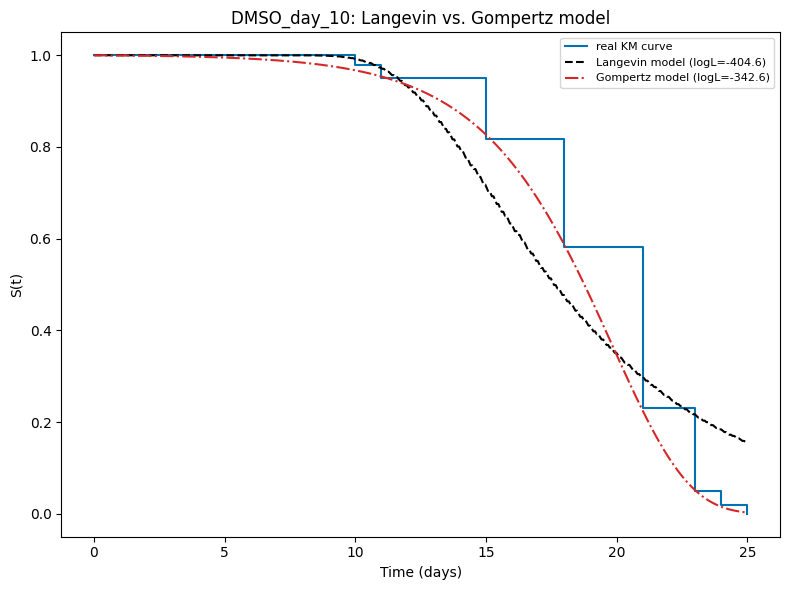

In [ ]:
kmf_dmso = kaplan_meier_curve(d_dmso)
t_plot = np.linspace(0, d_dmso.t.max(), 400)
T_plot_sim1, _, _ = simulate_fpt_and_state(
    N_PATHS, a0, g0, sigma_sq0, Z0, z0=0.0, dt=0.1, t_max=d_dmso.t.max(), rng=np.random.default_rng(1),
)
S_langevin1_plot = km_from_fpt(T_plot_sim1, t_plot, t_max=d_dmso.t.max())
S_gomp1_plot = gompertz_survival(t_plot, M0_dmso, alpha_g_dmso)

fig, ax = plt.subplots(figsize=(8, 6))
plot_survival_comparison(ax, kmf_dmso, t_plot, S_langevin1_plot, S_gomp1_plot,
                          logL_langevin1, logL_gomp1, color="#0072B2",
                          title="DMSO_day_10: Langevin vs. Gompertz model")
plt.tight_layout()
plt.show()

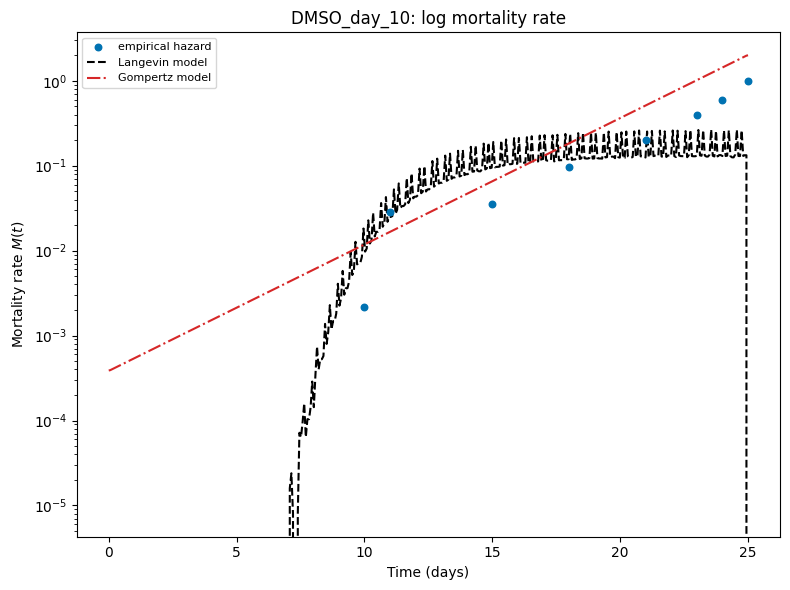

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_log_mortality_comparison(ax, d_dmso, t_plot, S_langevin1_plot, S_gomp1_plot,
                               color="#0072B2", title="DMSO_day_10: log mortality rate")
plt.tight_layout()
plt.show()

### Sanity check: mortality-doubling rate via lifelines' Cox/Nelson-Aalen baseline hazard

A direct `lifelines.CoxPHFitter` fit doesn't work here: Cox's partial
likelihood estimates a hazard *ratio* from covariates that vary *within*
each risk set at a given time, but DMSO_day_10 is a single homogeneous
cohort with no such covariate -- age is duration itself, so there's
nothing left to regress on (confirmed directly: fitting `CoxPHFitter` on
this data with no covariates raises a convergence error from a singular
information matrix, not a code bug).

What Cox's own baseline hazard reduces to with zero covariates is
exactly the **Nelson-Aalen estimator** (lifelines' documented
equivalence to the Breslow estimator) -- `lifelines.NelsonAalenFitter`
below gives that same nonparametric cumulative-hazard curve, independent
of our own hand-rolled `empirical_hazard` above (and using an exact
tie-correction for concurrent deaths within a risk set, `sum 1/(n-j)`,
rather than our simpler `d/n`, so it's not a redundant recomputation).
Fitting a straight line to `log(hazard)` vs. age (Gompertz's own
defining assumption) then gives a second, independent estimate of
`alpha_g` and the implied MRDT, to check against our own MLE Gompertz
fit above.

In [ ]:
def cox_equivalent_log_hazard_slope(d):
    """Nelson-Aalen cumulative hazard (== CoxPH's own baseline hazard with
    no covariates) -> per-bin discrete hazard -> OLS fit of log(hazard) vs.
    age, returning (alpha_g, M0, r_squared) for the fitted line."""
    naf = NelsonAalenFitter()
    naf.fit(durations=d.t, event_observed=d.event_observed, weights=d.weight)
    H = naf.cumulative_hazard_.iloc[:, 0]
    t_grid = H.index.to_numpy()
    keep = t_grid > 0  # drop the fitter's own t=0, H=0 anchor row (dt=0 there)
    t_grid, H = t_grid[keep], H.to_numpy()[keep]
    dt = np.diff(np.concatenate(([0.0], t_grid)))
    hazard = np.diff(np.concatenate(([0.0], H))) / dt

    mask = hazard > 0
    fit = linregress(t_grid[mask], np.log(hazard[mask]))
    return fit.slope, np.exp(fit.intercept), fit.rvalue ** 2


alpha_g_cox1, M0_cox1, r2_cox1 = cox_equivalent_log_hazard_slope(d_dmso)
mrdt_cox1 = np.log(2) / alpha_g_cox1
print(f"Cox/Nelson-Aalen log-hazard fit: M0={M0_cox1:.4g}, alpha_g={alpha_g_cox1:.4g}  (R^2={r2_cox1:.3f})")
print(f"Mortality rate doubling time (Cox/Nelson-Aalen): {mrdt_cox1:.3g} days")
print(f"  vs. our own Gompertz MLE fit: alpha_g={alpha_g_dmso:.4g}, MRDT={mrdt_gomp1:.3g} days")

Cox/Nelson-Aalen log-hazard fit: M0=0.0001499, alpha_g=0.3702  (R^2=0.925)
Mortality rate doubling time (Cox/Nelson-Aalen): 1.87 days
  vs. our own Gompertz MLE fit: alpha_g=0.3427, MRDT=2.02 days


## Part 2: Auxin_day_10 baseline (single phase)

Same construction as Part 1, against Auxin_day_10's own data. Our
model's `(alpha, g)` are `0_auto_fit_parameters_mle.py`'s own Step 1b
fit -- `sigma` fixed at Part 1's DMSO value, not refit here -- so `k=2`
for the AIC below (only 2 parameters were estimated from Auxin_day_10's
own data). The Gompertz counterpart is fit fresh to the same data,
`k=2`. These fitted `(alpha, Z)`/`(M0, alpha_g)` pairs are also exactly
what Part 3 reuses as its post-switch phase, without refitting.

In [ ]:
a0_auxin10, log_g0_auxin10 = 0.1035, -2.7358  # 0_auto_fit_parameters_mle.py, Step 1b
g0_auxin10 = 10.0 ** log_g0_auxin10
alpha1, Z1 = a0_auxin10, a0_auxin10 / g0_auxin10
print(f"Langevin (Auxin_day_10, from 0_auto_fit_parameters_mle.py): alpha={alpha1}, Z={Z1:.4g}")

d_auxin10 = raw_data["Auxin_day_10"]

nll_langevin2 = langevin_neg_log_lik_single(alpha1, Z1, sigma_sq0, d_auxin10, seed=0)
logL_langevin2 = -nll_langevin2
k_langevin2 = 2
aic_langevin2 = report_fit("Langevin model", logL_langevin2, k_langevin2,
                            note="sigma fixed at DMSO_day_10's fit")

bounds_gompertz_a10 = [(1e-4, 2.0), (1e-3, 2.0)]
popt_gomp_a10, nll_gomp_a10 = fit_gompertz_single(d_auxin10, bounds_gompertz_a10, seed=1)
M0_a10, alpha_g_a10 = popt_gomp_a10
logL_gomp2 = -nll_gomp_a10
k_gomp2 = 2
print(f"Gompertz fit: M0={M0_a10:.4g}, alpha_g={alpha_g_a10:.4g}")
aic_gomp2 = report_fit("Gompertz model", logL_gomp2, k_gomp2)

mrdt_gomp2 = np.log(2) / alpha_g_a10
mrdt_langevin2 = np.log(2) / alpha1
print(f"Mortality rate doubling time (Gompertz, ln2/alpha_g): {mrdt_gomp2:.3g} days")
print(f"Mortality rate doubling time (Langevin, ln2/alpha):   {mrdt_langevin2:.3g} days")

delta_aic2 = report_delta_aic("Auxin_day_10", aic_gomp2, aic_langevin2)

S_langevin2_grid = langevin_survival_single(alpha1, Z1, sigma_sq0, d_auxin10, seed=0)
S_gomp2_grid = gompertz_survival(np.concatenate(([0.0], np.unique(d_auxin10.t))), M0_a10, alpha_g_a10)

logL2_mc_mean, logL2_mc_se = langevin_logL_monte_carlo_se(
    langevin_neg_log_lik_single, alpha1, Z1, sigma_sq0, d_auxin10, n_paths=100_000,
)
report_mc_noise("Auxin_day_10", logL2_mc_mean, logL2_mc_se, logL_gomp2)

Langevin (Auxin_day_10, from 0_auto_fit_parameters_mle.py): alpha=0.1035, Z=56.33
Langevin model: logL=-212.6 (k=2, sigma fixed at DMSO_day_10's fit); nominal AIC=429.2 (descriptive)
Gompertz fit: M0=0.002256, alpha_g=0.1425
Gompertz model: logL=-164.5 (k=2); nominal AIC=333 (descriptive)
Mortality rate doubling time (Gompertz, ln2/alpha_g): 4.87 days
Mortality rate doubling time (Langevin, ln2/alpha):   6.7 days
Nominal delta AIC (Gompertz - Langevin), Auxin_day_10: -96.21; exploratory
MC diagnostic unavailable: 4/10 seeds have unresolved observed bins. Increase paths; finite seeds are not selectively averaged.
Simulation-spread diagnostic for Auxin_day_10: unavailable at this resolution.


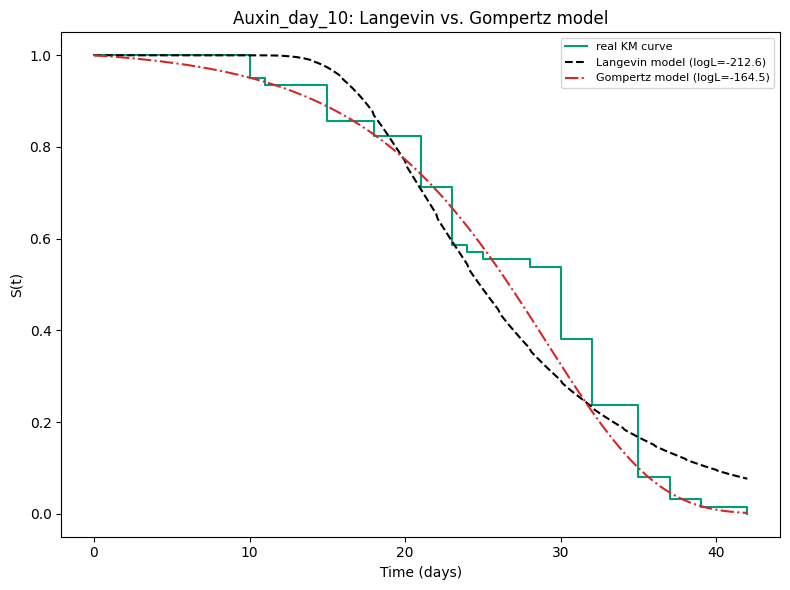

In [ ]:
kmf_auxin10 = kaplan_meier_curve(d_auxin10)
t_plot_a10 = np.linspace(0, d_auxin10.t.max(), 400)
T_plot_sim2, _, _ = simulate_fpt_and_state(
    N_PATHS, alpha1, alpha1 / Z1, sigma_sq0, Z1, z0=0.0, dt=0.1,
    t_max=d_auxin10.t.max(), rng=np.random.default_rng(1),
)
S_langevin2_plot = km_from_fpt(T_plot_sim2, t_plot_a10, t_max=d_auxin10.t.max())
S_gomp2_plot = gompertz_survival(t_plot_a10, M0_a10, alpha_g_a10)

fig, ax = plt.subplots(figsize=(8, 6))
plot_survival_comparison(ax, kmf_auxin10, t_plot_a10, S_langevin2_plot, S_gomp2_plot,
                          logL_langevin2, logL_gomp2, color="#009E73",
                          title="Auxin_day_10: Langevin vs. Gompertz model")
plt.tight_layout()
plt.show()

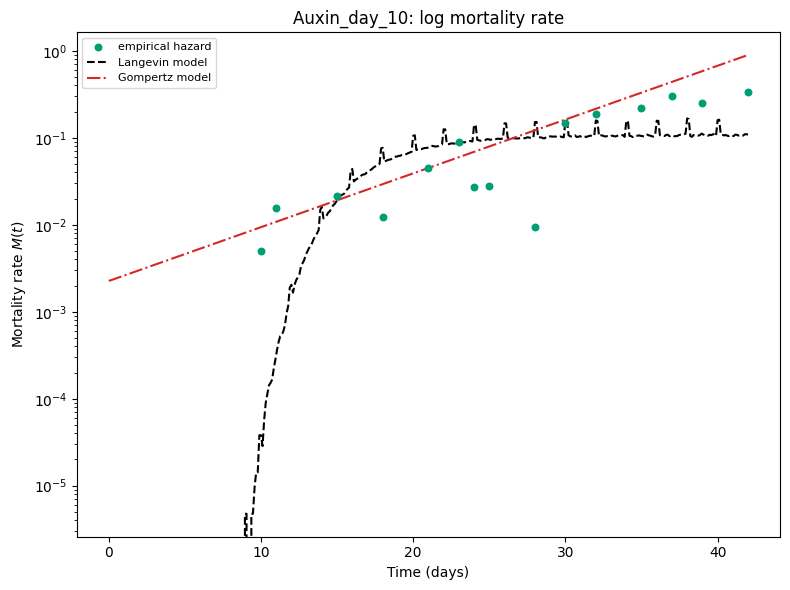

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_log_mortality_comparison(ax, d_auxin10, t_plot_a10, S_langevin2_plot, S_gomp2_plot,
                               color="#009E73", title="Auxin_day_10: log mortality rate")
plt.tight_layout()
plt.show()

## Part 3: DMSO_day_10 -> Auxin_day_21 (two phase, at the intervention)

`0_auto_fit_parameters_mle.py` does not fit Auxin_day_21 at all: our
model's phase-2 dynamics there are exactly Part 2's own Auxin_day_10 fit
`(alpha1, Z1)`, reused on the reasoning that worms switched onto auxin at
day 21 settle into the same post-auxin dynamics as worms given auxin at
day 10.

To keep this comparison matched, the Gompertz counterpart mirrors that
reasoning as closely as the Gompertz hazard shape allows: phase 1 is
Part 1's own DMSO Gompertz fit in full (`M0_dmso, alpha_g_dmso`); phase 2
reuses only Part 2's fitted mortality-rate-doubling constant
(`alpha_g_a10`) from the Auxin_day_10 fit, applied from the mortality
*level* phase 1 has already reached at `t_switch` -- not from a shared
baseline `M0` (see "Gompertz hazard model" above for why: a day-21 worm
carries forward its accumulated DMSO mortality risk; only the future
rate of increase changes at intervention). `M(t)` is therefore
continuous at `t_switch` and never decreases. **Neither model touches
Auxin_day_21's data at all** -- both make a genuine out-of-sample
prediction for that condition, so `k=0` for both and the comparison
reduces to a direct log-likelihood comparison.

In [ ]:
t_switch = 21.0
d_auxin21 = raw_data["Auxin_day_21"]

nll_langevin3 = langevin_neg_log_lik_two_phase(a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, seed=0)
logL_langevin3 = -nll_langevin3
k_langevin3 = 0
aic_langevin3 = report_fit("Langevin model", logL_langevin3, k_langevin3,
                            note="both phases fixed -- neither fit to Auxin_day_21")

nll_gomp3 = gompertz_neg_log_lik_two_phase(M0_dmso, alpha_g_dmso, alpha_g_a10, t_switch, d_auxin21)
logL_gomp3 = -nll_gomp3
k_gomp3 = 0
aic_gomp3 = report_fit("Gompertz model", logL_gomp3, k_gomp3,
                        note="both phases fixed -- neither fit to Auxin_day_21")

print(f"Mortality rate doubling time (Gompertz):  {mrdt_gomp1:.3g} -> {mrdt_gomp2:.3g} days at t_switch={t_switch:.0f}")
print(f"Mortality rate doubling time (Langevin):  {mrdt_langevin1:.3g} -> {mrdt_langevin2:.3g} days at t_switch={t_switch:.0f}")

delta_aic3 = report_delta_aic("Auxin_day_21", aic_gomp3, aic_langevin3)

S_langevin3_grid = langevin_survival_two_phase(a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, seed=0)
S_gomp3_grid = gompertz_survival_two_phase(
    np.concatenate(([0.0], np.unique(d_auxin21.t))), M0_dmso, alpha_g_dmso, alpha_g_a10, t_switch,
)

logL3_mc_mean, logL3_mc_se = langevin_logL_monte_carlo_se(
    langevin_neg_log_lik_two_phase, a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, n_paths=100_000,
)
report_mc_noise("Auxin_day_21", logL3_mc_mean, logL3_mc_se, logL_gomp3)

Langevin model: logL=-459.9 (k=0, both phases fixed -- neither fit to Auxin_day_21); nominal AIC=919.7 (descriptive)
Gompertz model: logL=-688.4 (k=0, both phases fixed -- neither fit to Auxin_day_21); nominal AIC=1377 (descriptive)
Mortality rate doubling time (Gompertz):  2.02 -> 4.87 days at t_switch=21
Mortality rate doubling time (Langevin):  4.46 -> 6.7 days at t_switch=21
Nominal delta AIC (Gompertz - Langevin), Auxin_day_21: +457.1; exploratory
Langevin logL simulation diagnostic, Auxin_day_21: mean=-460.1, between-run SD=0.277; mean logL difference=+228.3


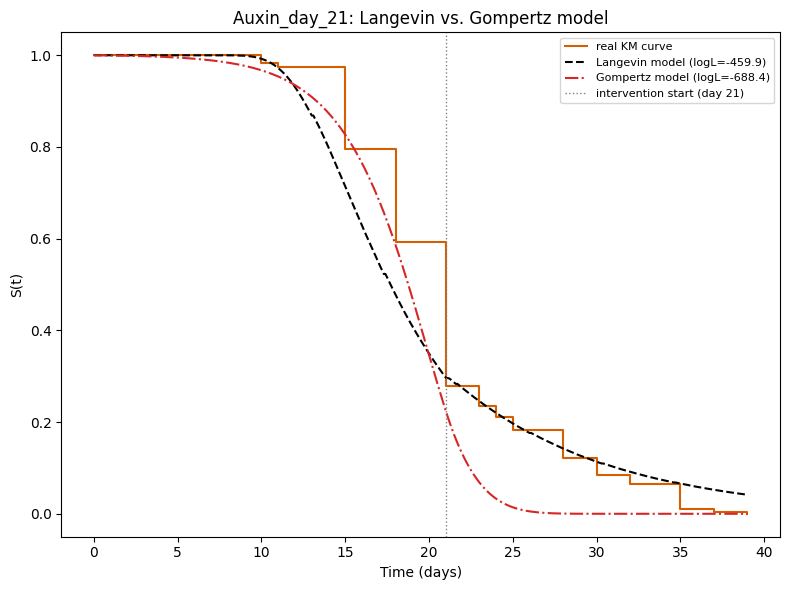

In [ ]:
kmf_auxin21 = kaplan_meier_curve(d_auxin21)
t_plot21 = np.linspace(0, d_auxin21.t.max(), 400)
T_plot_sim3 = _two_phase_paths_batched(
    a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21.t.max(), n_paths=N_PATHS, dt=0.1, seed=1,
)
S_langevin3_plot = km_from_fpt(T_plot_sim3, t_plot21, t_max=d_auxin21.t.max() + 0.1)
S_gomp3_plot = gompertz_survival_two_phase(t_plot21, M0_dmso, alpha_g_dmso, alpha_g_a10, t_switch)

fig, ax = plt.subplots(figsize=(8, 6))
plot_survival_comparison(ax, kmf_auxin21, t_plot21, S_langevin3_plot, S_gomp3_plot,
                          logL_langevin3, logL_gomp3, color="#D55E00",
                          title="Auxin_day_21: Langevin vs. Gompertz model", t_switch=t_switch)
plt.tight_layout()
plt.show()

Continuity check for Auxin_day_21 at t_switch=21: M(21-)=M(21+)=0.5123 (by construction)


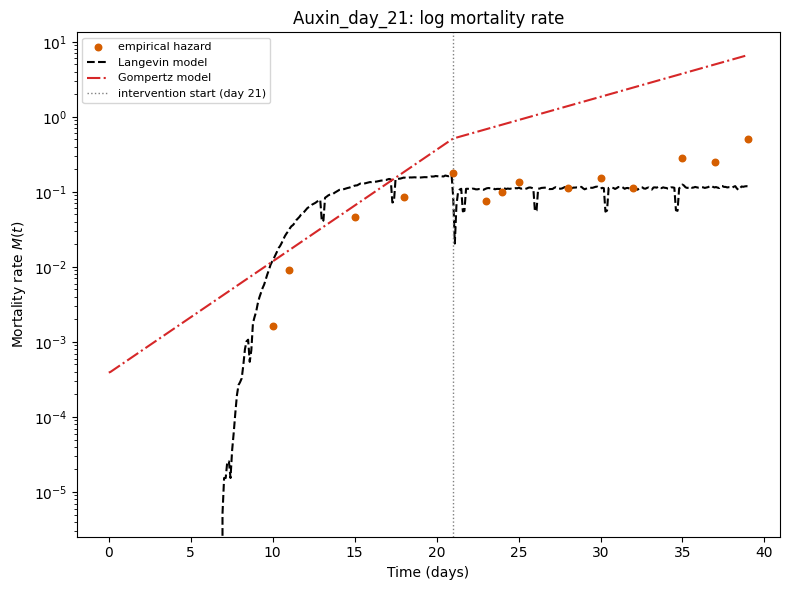

In [ ]:
M_switch_level = gompertz_hazard_two_phase(t_switch, M0_dmso, alpha_g_dmso, alpha_g_a10, t_switch)
print(f"Continuity check for Auxin_day_21 at t_switch={t_switch:.0f}: "
      f"M(21-)=M(21+)={float(M_switch_level):.4g} (by construction)")

fig, ax = plt.subplots(figsize=(8, 6))
plot_log_mortality_comparison(ax, d_auxin21, t_plot21, S_langevin3_plot, S_gomp3_plot,
                               color="#D55E00", title="Auxin_day_21: log mortality rate", t_switch=t_switch)
plt.tight_layout()
plt.show()

### Conditional post-day-21 survival: identical tests for both models

Condition on worms still alive AND under observation immediately after
day 21. Deaths/censoring at day 21 are excluded. H0 is the fixed model's
conditional survival distribution S(t)/S(21). The primary alternative
is a greater conditional restricted mean remaining lifetime through tau;
it does not assert that the observed curve is greater at every age.

These data record deaths at inspection ages, not exact death times.
We therefore compare inspection-time RMST: both the observed and model
survival functions are constant between the same inspection ages.
The model mean is sum(diff(ages) * S(ages[:-1])/S(21)), NOT the integral
of a smooth model against an endpoint-recorded empirical curve. This
avoids giving the empirical curve extra survival merely from rounding.
The reported effect is in days on this inspection-time scale; exact
continuous-time residual lifespan is not identifiable from these bins.

The bootstrap samples multinomial death-interval counts plus survival
past tau, exactly equivalent to drawing conditional model lifetimes and
recording them at the next inspection. An optional integrated squared
curve distance detects differences of either sign on this time grid.
Neither test can detect differences within an inspection interval.

Auxin_day_21 has no censoring after 21. The shared function also allows
administrative censoring at/after tau, but rejects earlier censoring:
that requires an explicit independent censoring model in the bootstrap.
It must not silently recycle observed censor times or treat them as deaths.

Inference is conditional on the fitted training parameters and, for
Langevin, its simulated survival probabilities. It does not propagate
training-fit uncertainty or finite-path simulation error. A full refit
bootstrap would need the original training/fitting pipeline for BOTH
families. Do not use this fixed-prediction test on a cohort used to fit
the supplied model. No refitting to Auxin_day_21 occurs here.

Set tau for scientific reasons before inspecting p-values. Day 35 is an
explicit analysis choice, not an optimized endpoint. Since these data
have already been inspected, treat this analysis as exploratory unless
that endpoint was independently specified. Both models use the same tau.
P-values are unadjusted; a larger p-value does not establish a better model.
References: https://lifelines.readthedocs.io/en/stable/lifelines.utils.html
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.monte_carlo_test.html

In [ ]:
def conditional_survival_bootstrap(d, S_at_grid, *, landmark=21.0, tau=35.0,
                                   n_boot=10_000, seed=20260919, omnibus=True):
    """Fixed-model, grouped conditional RMST Monte Carlo/parametric bootstrap.

    d: existing GroupedSurvivalData (integer frequency weights).
    S_at_grid: UNCLIPPED model S at [0, *np.unique(d.t)], as returned by
        langevin_survival_two_phase or gompertz_survival_two_phase above.
    landmark and tau must be actual inspection ages. Censoring in
    (landmark, tau) is unsupported and raises rather than miscalibrating.
    Returns scalar results plus curves and bootstrap arrays for reuse.
    """
    t = np.asarray(d.t, dtype=float)
    event = np.asarray(d.event_observed, dtype=float)
    weight = np.asarray(d.weight, dtype=float)
    if (t.ndim != 1 or t.size == 0 or event.shape != t.shape
            or weight.shape != t.shape):
        raise ValueError("t, event_observed and weight must be nonempty parallel vectors.")
    if (not np.all(np.isfinite(t)) or np.any(t <= 0)
            or not np.all(np.isin(event, [0, 1]))
            or not np.all(np.isfinite(weight)) or np.any(weight < 0)
            or np.any(weight != np.floor(weight))):
        raise ValueError("Require positive finite ages, binary events and nonnegative integer counts.")
    if (not np.isfinite(landmark) or not np.isfinite(tau)
            or tau <= landmark):
        raise ValueError("Require finite tau > landmark.")
    if isinstance(n_boot, (bool, np.bool_)) or not isinstance(n_boot, (int, np.integer)) or n_boot < 1:
        raise ValueError("n_boot must be a positive integer.")
    unique_t = np.unique(t)
    if landmark not in unique_t or tau not in unique_t:
        raise ValueError("landmark and tau must be recorded inspection ages; do not interpolate bins.")
    model_t = np.concatenate(([0.0], unique_t))
    model_s = np.asarray(S_at_grid, dtype=float)
    if (model_s.shape != model_t.shape or not np.all(np.isfinite(model_s))
            or np.any(model_s < 0) or np.any(model_s > 1)
            or np.any(np.diff(model_s) > 0) or not np.isclose(model_s[0], 1)):
        raise ValueError("Model survival must start at 1, be finite, nonincreasing and in [0, 1].")
    post = (t > landmark) & (weight > 0)
    n = int(weight[post].sum())
    if n == 0:
        raise ValueError("No worms remain observed after the landmark.")
    if np.any(post & (t < tau) & (event == 0)):
        raise ValueError("Censoring before tau requires an explicit censoring-model bootstrap.")
    ages = unique_t[(unique_t >= landmark) & (unique_t <= tau)]
    survival_at_ages = model_s[np.searchsorted(model_t, ages)]
    if survival_at_ages[0] <= 0:
        raise ValueError("Conditioning requires positive model S(landmark).")
    model_conditional = survival_at_ages / survival_at_ages[0]
    widths = np.diff(ages)
    deaths = np.array([weight[(t == age) & (event == 1)].sum()
                       for age in ages[1:]], dtype=int)
    observed_conditional = np.r_[1.0, 1.0 - np.cumsum(deaths) / n]
    observed_rmst = float(observed_conditional[:-1] @ widths)
    model_rmst = float(model_conditional[:-1] @ widths)
    delta = observed_rmst - model_rmst

    # Final category includes survival past tau. It is never forced to die
    # at the last inspection, even when the observed cohort is extinct.
    probabilities = np.r_[-np.diff(model_conditional), model_conditional[-1]]
    probabilities /= probabilities.sum()
    rng = np.random.default_rng(seed)
    counts = rng.multinomial(n, probabilities, size=n_boot)
    boot_survival = np.column_stack((np.ones(n_boot),
                                    1.0 - np.cumsum(counts[:, :-1], axis=1) / n))
    boot_delta = boot_survival[:, :-1] @ widths - model_rmst

    def upper_tail(samples, observed):
        # Include numerical ties; plus-one correction prevents zero p-values.
        tol = 100 * np.finfo(float).eps * max(1.0, abs(observed))
        exceedances = int(np.count_nonzero(samples >= observed - tol))
        return (1 + exceedances) / (n_boot + 1)

    p_greater = upper_tail(boot_delta, delta)
    result = {
        "n_landmark": n, "landmark": float(landmark), "tau": float(tau),
        "rmst_observed_days": observed_rmst, "rmst_model_days": model_rmst,
        "delta_rmst_days": delta, "p_rmst_greater": p_greater,
        "p_rmst_mc_se": float(np.sqrt(p_greater * (1 - p_greater) / n_boot)),
        "n_boot": n_boot, "seed": seed, "p_resolution": 1 / (n_boot + 1),
        "inference": "fixed prediction; inspection-time RMST; no training-fit uncertainty",
        "ages": ages, "observed_conditional": observed_conditional,
        "model_conditional": model_conditional, "bootstrap_delta_rmst": boot_delta,
    }
    if omnibus:
        distance = float((observed_conditional[:-1] - model_conditional[:-1]) ** 2 @ widths)
        boot_distance = (boot_survival[:, :-1] - model_conditional[:-1]) ** 2 @ widths
        result.update(curve_distance=distance,
                      p_curve_distance=upper_tail(boot_distance, distance),
                      bootstrap_curve_distance=boot_distance)
    return result


Conditional post-day-21 survival (fixed predictions, inspection-time RMST):
   model  n_landmark  tau  rmst_observed_days  rmst_model_days  delta_rmst_days  p_rmst_greater  p_curve_distance
Gompertz          59   35             7.79661          2.64662          5.14999       9.999e-05         9.999e-05
Langevin          59   35             7.79661          8.10414        -0.307532        0.690431          0.520448
Bootstrap p-value resolution: 9.999e-05; p-values are unadjusted.
Positive delta RMST means longer observed remaining survival on the inspection-time scale.
A nonsignificant p-value does not establish equivalence or rank the models.


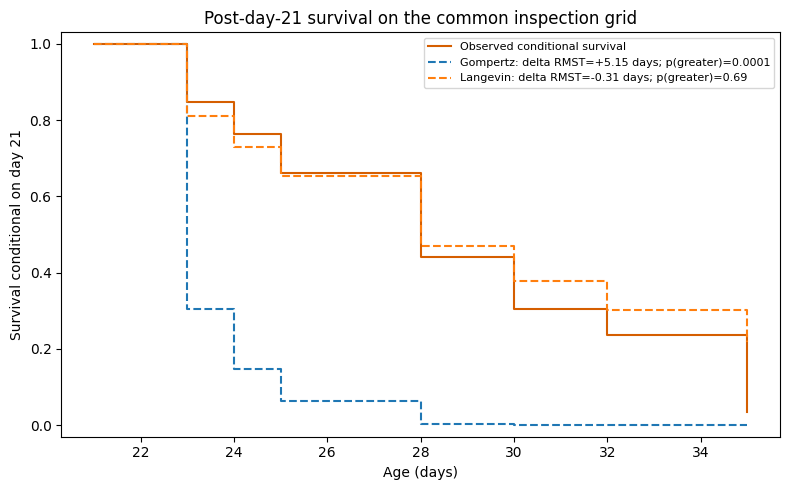

In [ ]:
POST21_TAU = 35.0  # Plot endpoint only; both 35 and 39 are reported below.
POST21_N_BOOT = 10_000
POST21_SEED = 20260919
post21_results = {
    name: conditional_survival_bootstrap(
        d_auxin21, prediction, landmark=t_switch, tau=POST21_TAU,
        n_boot=POST21_N_BOOT, seed=POST21_SEED, omnibus=True,
    )
    for name, prediction in [("Gompertz", S_gomp3_grid), ("Langevin", S_langevin3_grid)]
}
post21_summary = pd.DataFrame([
    {"model": name, **{key: value for key, value in result.items()
                       if not isinstance(value, np.ndarray)}}
    for name, result in post21_results.items()
])
print("\nConditional post-day-21 survival (fixed predictions, inspection-time RMST):")
print(post21_summary[["model", "n_landmark", "tau", "rmst_observed_days",
                      "rmst_model_days", "delta_rmst_days", "p_rmst_greater",
                      "p_curve_distance"]].to_string(index=False, float_format=lambda x: f"{x:.6g}"))
print(f"Bootstrap p-value resolution: {1 / (POST21_N_BOOT + 1):.6g}; p-values are unadjusted.")
print("Positive delta RMST means longer observed remaining survival on the inspection-time scale.")
print("A nonsignificant p-value does not establish equivalence or rank the models.")

fig, ax = plt.subplots(figsize=(8, 5))
first_result = next(iter(post21_results.values()))
ax.step(first_result["ages"], first_result["observed_conditional"], where="post",
        color="#D55E00", label="Observed conditional survival")
for name, result in post21_results.items():
    ax.step(result["ages"], result["model_conditional"], where="post", ls="--",
            label=f"{name}: delta RMST={result['delta_rmst_days']:+.2f} days; "
                  f"p(greater)={result['p_rmst_greater']:.3g}")
ax.set(xlabel="Age (days)", ylabel="Survival conditional on day 21",
       title="Post-day-21 survival on the common inspection grid", ylim=(-0.03, 1.03))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Single-endpoint check: exact binomial test at day 30

The RMST test above summarizes the whole post-day-21 curve. This is the
same comparison collapsed onto one prespecified age, which makes the size
of the discrepancy readable without any bootstrap machinery.

Each of the 59 worms observed alive past day 21 is treated as one
Bernoulli trial with success probability `p = S(30)/S(21)` taken straight
from the fixed Gompertz two-phase prediction (no refit, no free
parameters). Worms are assumed independent; replicate structure is not
recoverable from these aggregated life tables, so any real clustering
would make the test anticonservative.

"Survived until day 30" is ambiguous on an inspection grid, so both
readings are reported and neither is presented as the single right one:

* **At risk at day 30** -- worms that reached the day-30 inspection, i.e.
  survived past the previous inspection at day 28. The matching model
  probability is `S(28)/S(21)`. This is the reading that yields the
  quoted 26.
* **Alive after day 30** -- worms that survived the day-30 inspection,
  matching `S(30)/S(21)`. On this reading the observed count is 18.

Both counts are recomputed from `d_auxin21` rather than hardcoded, and
the stated 59/26 is asserted against the data.

The alternative is one-sided `greater`: the scientific claim under test is
that more worms survive than the Gompertz extrapolation of the DMSO
baseline allows. Direction was fixed by that claim, not by inspecting the
counts. A one-sided test cannot detect an excess of deaths.

This shares the day-30 data with the RMST test above, so it is a
restatement of the same evidence at one age, not independent confirmation;
p-values are unadjusted. Langevin is shown on the same rows for contrast,
but this test was set up for Gompertz and is not a model-selection rule.
Reference: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html

In [ ]:
BINOM_LANDMARK = 21.0
BINOM_ENDPOINT = 30.0


def _survival_at(S_at_grid, d, age):
    """Model S(age) off the [0, *unique ages] grid these predictions use."""
    grid = np.r_[0.0, np.unique(d.t)]
    idx = np.searchsorted(grid, age)
    if idx >= grid.size or grid[idx] != age:
        raise ValueError(f"{age} is not a recorded inspection age; do not interpolate bins.")
    return float(np.asarray(S_at_grid, dtype=float)[idx])


def binomial_endpoint_test(d, S_at_grid, *, landmark, endpoint, reference_age,
                           alternative="greater"):
    """Exact one-sided binomial test of one fixed-model survival probability.

    reference_age is the grid age whose model survival defines the success
    probability: `endpoint` for "alive after endpoint", or the preceding
    inspection age for "at risk at endpoint" (see the markdown above).
    Requires no censoring in (landmark, endpoint], so that the observed
    count is an unambiguous binomial numerator.
    """
    t = np.asarray(d.t, dtype=float)
    event = np.asarray(d.event_observed, dtype=float)
    weight = np.asarray(d.weight, dtype=float)
    post = (t > landmark) & (weight > 0)
    n = int(weight[post].sum())
    if n == 0:
        raise ValueError("No worms remain observed after the landmark.")
    if np.any(post & (t <= endpoint) & (event == 0)):
        raise ValueError("Censoring in (landmark, endpoint] makes the binomial count ambiguous.")
    successes = n - int(weight[post & (t <= reference_age) & (event == 1)].sum())
    p_model = _survival_at(S_at_grid, d, reference_age) / _survival_at(S_at_grid, d, landmark)
    if not 0.0 < p_model <= 1.0:
        # A simulated S can hit exactly 0 on a finite path budget; binomtest
        # would then report p=0, which is a resolution artifact, not evidence.
        return {"n_trials": n, "successes": successes, "p_model": p_model,
                "expected_survivors": n * p_model, "p_value": np.nan,
                "note": "model probability is zero to simulation resolution; test undefined"}
    test = binomtest(successes, n, p_model, alternative=alternative)
    return {"n_trials": n, "successes": successes, "p_model": p_model,
            "expected_survivors": n * p_model, "p_value": test.pvalue,
            "observed_fraction": successes / n, "alternative": alternative}


unique21 = np.unique(d_auxin21.t)
prior_inspection = float(unique21[unique21 < BINOM_ENDPOINT].max())

binom_rows = []
for reading, reference_age in [("at risk at day 30", prior_inspection),
                               ("alive after day 30", BINOM_ENDPOINT)]:
    for name, prediction in [("Gompertz", S_gomp3_grid), ("Langevin", S_langevin3_grid)]:
        binom_rows.append({
            "reading": reading, "model": name,
            "S_ref_age": reference_age,
            **binomial_endpoint_test(d_auxin21, prediction, landmark=BINOM_LANDMARK,
                                     endpoint=BINOM_ENDPOINT, reference_age=reference_age,
                                     alternative="greater"),
        })
binom_summary = pd.DataFrame(binom_rows)

n_post21 = int(binom_summary["n_trials"].iloc[0])
n_at_risk_30 = int(binom_summary.loc[binom_summary.reading == "at risk at day 30", "successes"].iloc[0])
assert n_post21 == 59, f"expected 59 worms alive past day 21, got {n_post21}"
assert n_at_risk_30 == 26, f"expected 26 worms at risk at day 30, got {n_at_risk_30}"

print(f"\nConditional day-{BINOM_ENDPOINT:.0f} survival given alive past day "
      f"{BINOM_LANDMARK:.0f} (n={n_post21}); one-sided exact binomial, alternative=greater:")
print(binom_summary[["reading", "model", "S_ref_age", "p_model", "expected_survivors",
                     "successes", "observed_fraction", "p_value"]]
      .to_string(index=False, float_format=lambda x: f"{x:.6g}"))
print("p_model is the fixed prediction's conditional survival probability; nothing is refit here.")
print("Shares data with the RMST test above; not independent evidence. p-values unadjusted.")


Conditional day-30 survival given alive past day 21 (n=59); one-sided exact binomial, alternative=greater:
           reading    model  S_ref_age     p_model  expected_survivors  successes  observed_fraction     p_value
 at risk at day 30 Gompertz         28  0.00212977            0.125657         26           0.440678 1.27342e-53
 at risk at day 30 Langevin         28    0.470686             27.7705         26           0.440678    0.722393
alive after day 30 Gompertz         30 8.56491e-05          0.00505329         18           0.305085 3.97023e-59
alive after day 30 Langevin         30    0.377488             22.2718         18           0.305085    0.901529
p_model is the fixed prediction's conditional survival probability; nothing is refit here.
Shares data with the RMST test above; not independent evidence. p-values unadjusted.


### Diagnostic: DMSO, Auxin_day_10, and the switch, as log-mortality lines

Isolates the Gompertz machinery from everything else (no Langevin curve,
no empirical scatter) -- three lines:

1. `DMSO_day_10`'s own fitted line (`M0_dmso, alpha_g_dmso`).
2. `Auxin_day_10`'s own fitted line (`M0_a10, alpha_g_a10`) -- a
   different y-intercept *and* slope from DMSO's line, describing worms
   that received auxin from day 0.
3. The switch curve: line 1 up to `t_switch`, then continuing from line
   1's own value *at* `t_switch` (not from `M0_dmso` or `M0_a10`) at the
   new rate `alpha_g_a10`. It therefore leaves `t_switch` at exactly
   line 1's height, not line 2's -- lines 2 and 3 describe different
   worms (auxin from day 0 vs. auxin only from day 21) and are not
   expected to coincide at any age; the only continuity guarantee is
   between line 3 and line 1, at `t_switch`.

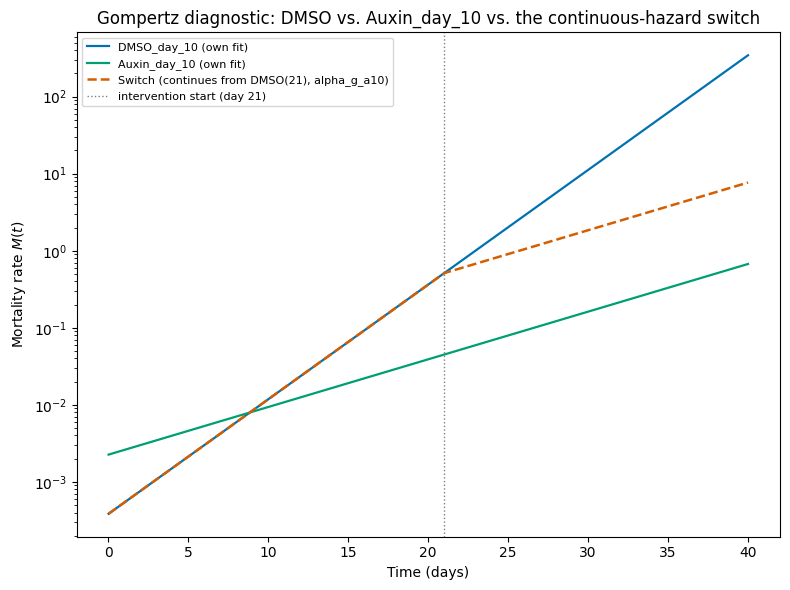

In [ ]:
t_diag = np.linspace(0.01, 40, 400)
M_dmso_line = M0_dmso * np.exp(alpha_g_dmso * t_diag)
M_auxin10_line = M0_a10 * np.exp(alpha_g_a10 * t_diag)
M_switch_line = gompertz_hazard_two_phase(t_diag, M0_dmso, alpha_g_dmso, alpha_g_a10, t_switch)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_diag, M_dmso_line, color="#0072B2", lw=1.6, label="DMSO_day_10 (own fit)")
ax.plot(t_diag, M_auxin10_line, color="#009E73", lw=1.6, label="Auxin_day_10 (own fit)")
ax.plot(t_diag, M_switch_line, color="#D55E00", lw=1.8, ls="--", label="Switch (continues from DMSO(21), alpha_g_a10)")
ax.axvline(t_switch, color="gray", lw=1, ls=":", label=f"intervention start (day {t_switch:.0f})")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Mortality rate $M(t)$")
ax.set_yscale("log")
ax.set_title("Gompertz diagnostic: DMSO vs. Auxin_day_10 vs. the continuous-hazard switch")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Held-out conditional predictive comparison (replaces Vuong claims)

H0: equal expected per-worm log predictive score for the two fixed models.
A positive difference favors Langevin; this is a relative comparison, not
evidence that either model is absolutely adequate or mechanistically correct.
The CI resamples each worm's PAIRED scores, never the two models separately.
The normal z/p is a diagnostic approximation; use the bootstrap CI and inspect
the per-interval contributions for dominance by sparse late observations.

All recorded post-day-21 outcomes form the full-follow-up comparison. This
scores each observed death interval without truncating/renormalizing the model
distribution at the last death. Days 35 and 39 are separately reported as
retrospective sensitivity analyses; the bootstrap does not recreate endpoint
selection or account for a population-level stopping rule. Both RMST endpoints
remain exploratory. Training fits and simulation probabilities are held fixed.

Reference for paired percentile bootstrap:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html

In [ ]:
PREDICTIVE_N_BOOT = 20_000
PREDICTIVE_SEED = 20260919
prediction_grid = np.r_[0., np.unique(d_auxin21.t)]
log_S_gomp3 = -gompertz_cumulative_hazard_two_phase(
    prediction_grid, M0_dmso, alpha_g_dmso, alpha_g_a10, t_switch)
log_S_langevin3 = _log_survival_from_S(S_langevin3_grid)
predictive_results = {
    label: conditional_predictive_comparison(
        d_auxin21, log_S_langevin3, log_S_gomp3, landmark=t_switch, tau=tau,
        n_boot=PREDICTIVE_N_BOOT, seed=PREDICTIVE_SEED)
    for label, tau in [("full_followup", None), ("through_35", 35.), ("through_39", 39.)]
}
predictive_summary = pd.DataFrame([
    {"analysis": label, "model_a": "Langevin", "model_b": "Gompertz",
     **{key: value for key, value in result.items()
        if not isinstance(value, (np.ndarray, pd.DataFrame))}}
    for label, result in predictive_results.items()
])
print("\nHeld-out post-day-21 paired log scores: positive favors Langevin (nats/worm).")
print(predictive_summary[["analysis", "n_landmark", "mean_log_score_difference", "ci_low", "ci_high",
                          "standard_error", "bootstrap_standard_error",
                          "normal_p_two_sided_diagnostic"]].to_string(index=False))
print("95% paired percentile-bootstrap intervals; fixed predictions; iid worms; exploratory.")

post21_sensitivity_results = {
    (name, tau): conditional_survival_bootstrap(
        d_auxin21, s, landmark=t_switch, tau=tau, n_boot=POST21_N_BOOT, seed=POST21_SEED)
    for name, s in [("Gompertz", S_gomp3_grid), ("Langevin", S_langevin3_grid)]
    for tau in [35., 39.]
}
post21_sensitivity_summary = pd.DataFrame([
    {"model": name, **{key: value for key, value in result.items() if not isinstance(value, np.ndarray)}}
    for (name, tau), result in post21_sensitivity_results.items()
])
print("\nExploratory RMST endpoint sensitivity (both endpoints reported):")
print(post21_sensitivity_summary[["model", "tau", "delta_rmst_days", "p_rmst_greater",
                                  "p_curve_distance"]].to_string(index=False))


Held-out post-day-21 paired log scores: positive favors Langevin (nats/worm).
     analysis  n_landmark  mean_log_score_difference   ci_low  ci_high  standard_error  bootstrap_standard_error  normal_p_two_sided_diagnostic
full_followup          59                   4.040453 2.597451 5.594236        0.774770                  0.770860                   1.837845e-07
   through_35          59                   3.951093 2.577995 5.399166        0.729624                  0.726393                   6.120460e-08
   through_39          59                   4.040453 2.597451 5.594236        0.774770                  0.770860                   1.837845e-07
95% paired percentile-bootstrap intervals; fixed predictions; iid worms; exploratory.

Exploratory RMST endpoint sensitivity (both endpoints reported):
   model  tau  delta_rmst_days  p_rmst_greater  p_curve_distance
Gompertz 35.0         5.149994        0.000100          0.000100
Gompertz 39.0         5.251689        0.000100          0.00010

In [ ]:
# Optional fixed-parameter Monte Carlo sensitivity, not biological uncertainty.
# Recompute probability estimates at independent seeds. Never average log scores
# to manufacture a production estimate or increase paths until p crosses .05.
RUN_PREDICTIVE_MC_CHECK = False
PREDICTIVE_MC_PATHS = 100_000
predictive_mc_rows = []
if RUN_PREDICTIVE_MC_CHECK:
    for mc_seed in [101, 102, 103]:
        s_mc = langevin_survival_two_phase(a0, Z0, alpha1, Z1, sigma_sq0, t_switch,
                                            d_auxin21, n_paths=PREDICTIVE_MC_PATHS, seed=mc_seed)
        result = conditional_predictive_comparison(
            d_auxin21, _log_survival_from_S(s_mc), log_S_gomp3,
            landmark=t_switch, n_boot=PREDICTIVE_N_BOOT, seed=PREDICTIVE_SEED)
        predictive_mc_rows.append({"simulation_seed": mc_seed, "n_paths": PREDICTIVE_MC_PATHS,
                                   "mean_log_score_difference": result["mean_log_score_difference"],
                                   "ci_low": result["ci_low"], "ci_high": result["ci_high"]})
    print(pd.DataFrame(predictive_mc_rows).to_string(index=False))

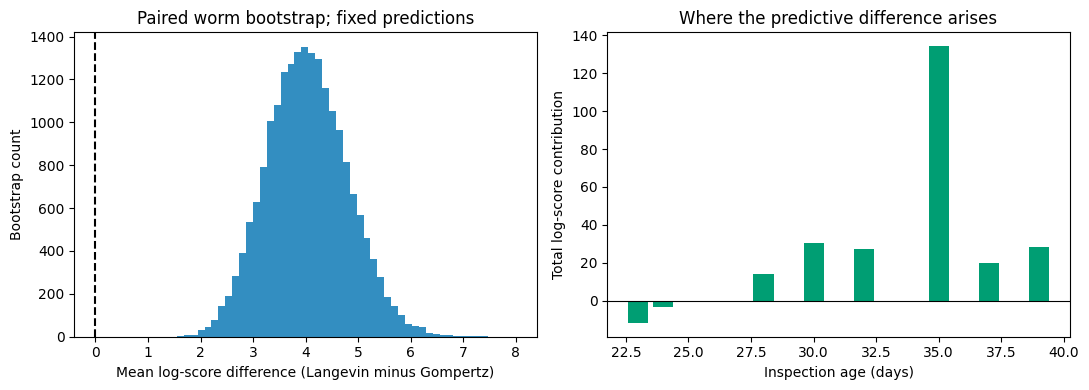

In [ ]:
# New outputs are separate from previously generated manuscript files.
NOTES_DIR = NOTEBOOK_DIR / "notes"
NOTES_DIR.mkdir(exist_ok=True)
predictive_summary.to_csv(NOTES_DIR / "post21_predictive_comparison.csv", index=False)
post21_sensitivity_summary.to_csv(NOTES_DIR / "post21_rmst_sensitivity.csv", index=False)
for label, result in predictive_results.items():
    result["contributions"].to_csv(NOTES_DIR / f"post21_predictive_contributions_{label}.csv", index=False)
if predictive_mc_rows:
    pd.DataFrame(predictive_mc_rows).to_csv(NOTES_DIR / "post21_predictive_mc_sensitivity.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
full = predictive_results["full_followup"]
axes[0].hist(full["bootstrap_mean_differences"], bins=50, color="#0072B2", alpha=.8)
axes[0].axvline(0, color="black", ls="--")
axes[0].set(xlabel="Mean log-score difference (Langevin minus Gompertz)",
            ylabel="Bootstrap count", title="Paired worm bootstrap; fixed predictions")
contributions = full["contributions"].groupby("age")["total_log_score_difference"].sum()
axes[1].bar(contributions.index, contributions.values, color="#009E73")
axes[1].axhline(0, color="black", lw=.8)
axes[1].set(xlabel="Inspection age (days)", ylabel="Total log-score contribution",
            title="Where the predictive difference arises")
fig.tight_layout()
fig.savefig(NOTES_DIR / "post21_predictive_comparison.png", dpi=180)
plt.show()

## Paper figure and supplementary table

These exports use the objects computed above; they do not refit or resimulate.
Panel A/B show training conditions; panel C is the held-out prediction.
Curves are unconditional S(t), whereas the inferential table explicitly
conditions on survival and observation after day 21. No obsolete Vuong
p-values or automatic manuscript significance claims are restored.

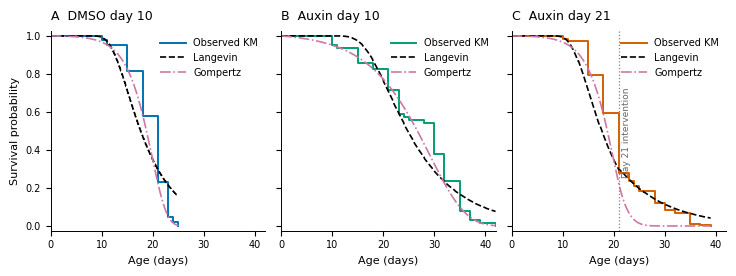

Paper figure and supplementary table written to /Users/djakim/NUS/Projects/01_ACTIVE/c_elegans_unstable/notebooks/notes


In [ ]:
def export_paper_outputs(output_dir):
    """Export publication figure and a three-part supplementary table.

    Requires the preceding analysis cells. Baseline unresolved simulation
    likelihoods are shown as unavailable, never as a finite AIC.
    SVG is vector artwork; PNG is 600 dpi. LaTeX requires booktabs.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    style = {
        "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
        "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
        "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.linewidth": .7, "svg.fonttype": "none",
    }
    panels = [
        ("A", "DMSO day 10", kmf_dmso, t_plot, S_langevin1_plot, S_gomp1_plot, "#0072B2"),
        ("B", "Auxin day 10", kmf_auxin10, t_plot_a10, S_langevin2_plot, S_gomp2_plot, "#009E73"),
        ("C", "Auxin day 21", kmf_auxin21, t_plot21, S_langevin3_plot, S_gomp3_plot, "#D55E00"),
    ]
    with plt.rc_context(style):
        fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.8), sharex=True, sharey=True)
        for ax, (letter, title, km, times, lang, gomp, color) in zip(axes, panels):
            sf = km.survival_function_
            ax.step(sf.index, sf.iloc[:, 0], where="post", color=color, lw=1.4,
                    label="Observed KM")
            ax.plot(times, lang, color="black", lw=1.2, ls="--", label="Langevin")
            ax.plot(times, gomp, color="#CC79A7", lw=1.2, ls="-.", label="Gompertz")
            ax.set_title(f"{letter}  {title}", loc="left", pad=8)
            ax.set_xlabel("Age (days)")
            ax.set_ylim(-.025, 1.025)
            ax.set_xlim(0, max(float(p[3][-1]) for p in panels))
            ax.set_xticks(np.arange(0, max(float(p[3][-1]) for p in panels)+1, 10))
            if letter == "C":
                ax.axvline(t_switch, color=".5", ls=":", lw=.9)
                ax.text(t_switch + .7, .49, "Day 21 intervention", rotation=90,
                        va="center", ha="left", color=".4", fontsize=6.5)
            ax.legend(loc="upper right", frameon=False, handlelength=2.6, borderaxespad=.3)
        axes[0].set_ylabel("Survival probability")
        fig.tight_layout(w_pad=1.0)
        fig.savefig(output_dir / "supp_note2_survival_curves.png", dpi=600, bbox_inches="tight")
        fig.savefig(output_dir / "supp_note2_survival_curves.svg", bbox_inches="tight")
        plt.show()

    fit_rows = []
    for condition, d, log_l, log_g, k_l, k_g in [
        ("DMSO day 10", d_dmso, logL_langevin1, logL_gomp1, k_langevin1, k_gomp1),
        ("Auxin day 10", d_auxin10, logL_langevin2, logL_gomp2, k_langevin2, k_gomp2),
        ("Auxin day 21", d_auxin21, logL_langevin3, logL_gomp3, k_langevin3, k_gomp3),
    ]:
        for model, value, k in [("Langevin", log_l, k_l), ("Gompertz", log_g, k_g)]:
            fit_rows.append([condition, model, str(d.n_total),
                             f"{value:.2f}" if np.isfinite(value) else "--", str(k),
                             f"{aic(value, k):.2f}" if np.isfinite(value) else "--"])

    def p_text(value):
        return f"{value:.2e}" if value < .001 else f"{value:.3f}"

    rmst_rows = []
    for _, row in post21_sensitivity_summary.sort_values(["tau", "model"]).iterrows():
        rmst_rows.append([row["model"], f"{row['tau']:.0f}",
                          f"{row['rmst_observed_days']:.2f}", f"{row['rmst_model_days']:.2f}",
                          f"{row['delta_rmst_days']:+.2f}", p_text(row["p_rmst_greater"]),
                          p_text(row["p_curve_distance"])])
    predictive_rows = []
    labels = {"full_followup": "Full follow-up", "through_35": "Through day 35", "through_39": "Through day 39"}
    for _, row in predictive_summary.iterrows():
        predictive_rows.append([labels[row["analysis"]], str(int(row["n_landmark"])),
                                f"{row['mean_log_score_difference']:+.2f}",
                                f"[{row['ci_low']:.2f}, {row['ci_high']:.2f}]",
                                p_text(row["normal_p_two_sided_diagnostic"])])
    sections = [
        ("A. Whole-cohort model scores", ["Condition", "Model", "N", "log L", "k", "Nominal AIC"], fit_rows),
        ("B. Conditional post-day-21 survival", ["Model", "End day", "Observed RMST", "Predicted RMST",
                                                 "Delta RMST", "p (greater)", "p (curve)"], rmst_rows),
        ("C. Paired predictive comparison (Langevin minus Gompertz)",
         ["Follow-up", "N", "Mean difference", "95% bootstrap CI", "Normal p"], predictive_rows),
    ]
    notes = (
        "A: Whole-cohort grouped log-likelihoods use unmodified model probabilities. "
        "k counts parameters estimated from the named condition; Auxin day 21 is held out (k=0). "
        "Langevin retains the original simulation-based training parameters; Gompertz is refitted without floors. "
        "Nominal AIC is descriptive, not a significance test. -- denotes unresolved simulated probability, "
        "for which no finite score is reported. "
        "B: RMST is inspection-time restricted remaining survival in days, conditional on the 59 animals "
        "observed after day 21. Delta is observed minus predicted. The one-sided test concerns greater RMST; "
        f"the curve test uses integrated squared distance. {POST21_N_BOOT:,} replicates; "
        f"minimum reported p={1/(POST21_N_BOOT+1):.2e}. "
        "C: Differences are nats per worm; positive values favor Langevin. "
        f"Intervals use {PREDICTIVE_N_BOOT:,} paired worm-bootstrap replicates; normal p is a two-sided "
        "asymptotic diagnostic, not a bootstrap p-value. Full follow-up and day 39 coincide numerically "
        "because all observed deaths occurred by day 39. "
        "B/C assume independent worms and fixed fitted predictions, excluding training-fit and "
        "simulation uncertainty. Endpoints are retrospective, p-values unadjusted, and analyses exploratory."
    )
    figure_caption = (
        "Survival curves for (A) DMSO day 10, (B) Auxin day 10, and (C) Auxin day 21. "
        "Colored steps show observed Kaplan-Meier survival; black dashed curves show Langevin predictions; "
        "magenta dash-dot curves show Gompertz predictions. Panels A and B show training conditions. "
        "Panel C shows held-out two-phase predictions using parameters from the training conditions, "
        "with a vertical dotted line at intervention on day 21. All curves show unconditional survival "
        "from the original cohort; the conditional post-day-21 tests are reported in the supplementary table. "
        f"Langevin curves use {N_PATHS:,} simulated paths per curve."
    )
    markdown = ["# Supplementary table: model predictions and post-intervention survival\n"]
    latex = [r"% Generated by 99_markov_vs_age_dependent_v4.py; requires \usepackage{booktabs}",
             r"\begin{table*}[htbp]", r"\centering", r"\small"]
    def tex_escape(text):
        return str(text).replace("&", r"\&").replace("%", r"\%").replace("_", r"\_")
    for title, headers, rows in sections:
        markdown.extend([f"## {title}\n", "| " + " | ".join(headers) + " |",
                         "| " + " | ".join(["---"]*len(headers)) + " |"])
        markdown.extend("| " + " | ".join(row) + " |" for row in rows)
        markdown.append("")
        latex.extend([r"\textbf{" + tex_escape(title) + r"}\par\smallskip",
                      r"\begin{tabular}{" + "l" + "r"*(len(headers)-1) + "}", r"\toprule",
                      " & ".join(map(tex_escape, headers)) + r" \\", r"\midrule"])
        latex.extend(" & ".join(map(tex_escape, row)) + r" \\" for row in rows)
        latex.extend([r"\bottomrule", r"\end{tabular}\par\medskip"])
    markdown.extend([notes, "\n# Figure caption\n", figure_caption])
    latex.extend([r"\caption{Model predictions and post-intervention survival. " + tex_escape(notes) + "}",
                  r"\label{tab:supp_note2_corrected_comparison}", r"\end{table*}"])
    (output_dir / "supp_note2_table.md").write_text("\n".join(markdown) + "\n")
    (output_dir / "supp_note2_table.tex").write_text("\n".join(latex) + "\n")
    (output_dir / "supp_note2_figure_caption.txt").write_text(figure_caption + "\n")
    print(f"Paper figure and supplementary table written to {output_dir}")
    return sections


paper_table_sections = export_paper_outputs(NOTES_DIR)